In [8]:
import cv2
import numpy as np
import os
import random
import math
from skimage.metrics import structural_similarity as ssim

# -------------------------------
# Mean Filter
# -------------------------------
def apply_mean_filter(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size ** 2)
    return cv2.filter2D(image, -1, kernel)

# -------------------------------
# Log Transformation
# -------------------------------
def apply_log_transformed(image):
    image2 = image.astype(np.float32)
    r_max = np.max(image2)

    if r_max > 0:
        c = 255 / np.log(1 + r_max)
        log_transformed = c * np.log(1 + image2)
        return np.array(log_transformed, dtype=np.uint8)
    else:
        return image

# -------------------------------
# Contrast Stretching
# -------------------------------
def contrast_stretching(image):
    minval = np.min(image)
    maxval = np.max(image)

    if maxval == minval:
        return image

    dmin = 50
    dmax = 200

    stretched = dmin + (image - minval) * ((dmax - dmin) / (maxval - minval))
    stretched = np.clip(stretched, 0, 255)

    return stretched.astype(np.uint8)

# -------------------------------
# Evaluation Metrics
# -------------------------------
def calculate_metrics(original, enhanced):

    mse = np.mean((original.astype("float") - enhanced.astype("float")) ** 2)

    if mse == 0:
        psnr = 100
    else:
        psnr = 20 * math.log10(255.0 / math.sqrt(mse))

    ssim_value = ssim(original, enhanced, data_range=255)

    return mse, psnr, ssim_value


# -------------------------------
# Create Output Folders
# -------------------------------
folders = ["frames", "gray_frames", "mean_filter", "log_frames", "stretched_frames"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)


# -------------------------------
# Open Video
# -------------------------------
video_file_path = 'IMG_5985.mov'
cap = cv2.VideoCapture(video_file_path)

if not cap.isOpened():
    print("Error: Could not open video.")
    exit()


# -------------------------------
# Get Total Frames
# -------------------------------
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Total Frames in Video:", total_frames)

if total_frames < 30:
    print("Video has less than 30 frames.")
    cap.release()
    exit()


# -------------------------------
# Select 30 Random Frames
# -------------------------------
random_frames = random.sample(range(total_frames), 30)
random_frames.sort()

print("Selected Frame Numbers:", random_frames)


# -------------------------------
# Process Each Frame
# -------------------------------
for i, frame_no in enumerate(random_frames):

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
    ret, frame = cap.read()

    if not ret:
        continue

    print(f"\nProcessing Frame {i+1} (Video Frame {frame_no})")

    # File Paths
    file_path = f"./frames/frame_{i+1}.jpg"
    gray_file_path = f"./gray_frames/gray_frame_{i+1}.jpg"
    mean_file_path = f"./mean_filter/mean_frame_{i+1}.jpg"
    log_file_path = f"./log_frames/log_frame_{i+1}.jpg"
    stretched_file_path = f"./stretched_frames/stretched_frame_{i+1}.jpg"

    # Save Original Frame
    cv2.imwrite(file_path, frame)

    # Convert to Grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    cv2.imwrite(gray_file_path, gray_frame)

    # Mean Filter
    mf_frame = apply_mean_filter(gray_frame, 3)
    cv2.imwrite(mean_file_path, mf_frame)

    # Log Transformation
    log_frame = apply_log_transformed(mf_frame)
    cv2.imwrite(log_file_path, log_frame)

    # Contrast Stretching
    stretched_frame = contrast_stretching(log_frame)
    cv2.imwrite(stretched_file_path, stretched_frame)

    # Metrics Calculation
    mse, psnr, ssim_value = calculate_metrics(gray_frame, stretched_frame)

    print("MSE :", mse)
    print("PSNR:", psnr)
    print("SSIM:", ssim_value)


# -------------------------------
# Release Video
# -------------------------------
cap.release()

print("\n30 Random frames processed successfully.")

Total Frames in Video: 708
Selected Frame Numbers: [67, 68, 83, 96, 143, 172, 187, 189, 193, 216, 228, 325, 357, 372, 379, 388, 407, 458, 499, 504, 566, 573, 574, 577, 619, 628, 641, 644, 669, 676]

Processing Frame 1 (Video Frame 67)
MSE : 1286.6077469135803
PSNR: 17.03634198824787
SSIM: 0.8873081365257305

Processing Frame 2 (Video Frame 68)
MSE : 1291.7988913001543
PSNR: 17.018854533983795
SSIM: 0.883928249748522

Processing Frame 3 (Video Frame 83)
MSE : 1631.9792881944445
PSNR: 16.003657181412088
SSIM: 0.5162687834924657

Processing Frame 4 (Video Frame 96)
MSE : 1823.8755979938271
PSNR: 15.52085148008903
SSIM: 0.4395350507046154

Processing Frame 5 (Video Frame 143)
MSE : 2003.3125549768517
PSNR: 15.113316480635493
SSIM: 0.47184480249060884

Processing Frame 6 (Video Frame 172)
MSE : 2082.843611111111
PSNR: 14.944236984003522
SSIM: 0.5086290041023153

Processing Frame 7 (Video Frame 187)
MSE : 1733.293555169753
PSNR: 15.742082386653731
SSIM: 0.5449268568138425

Processing Frame 8

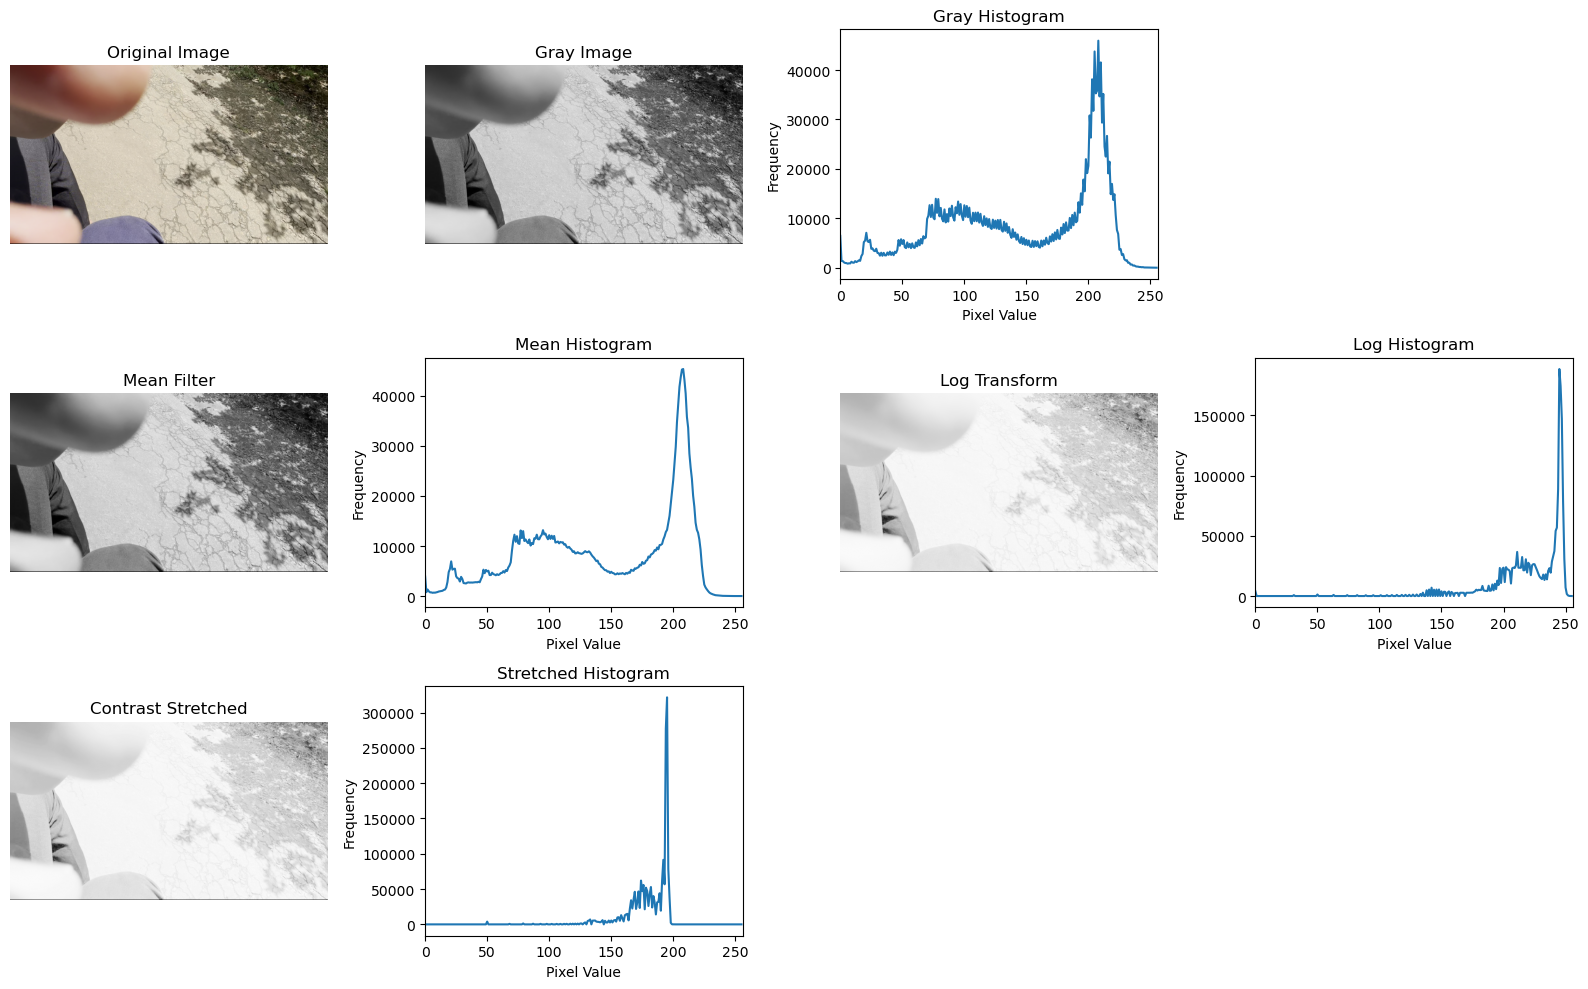

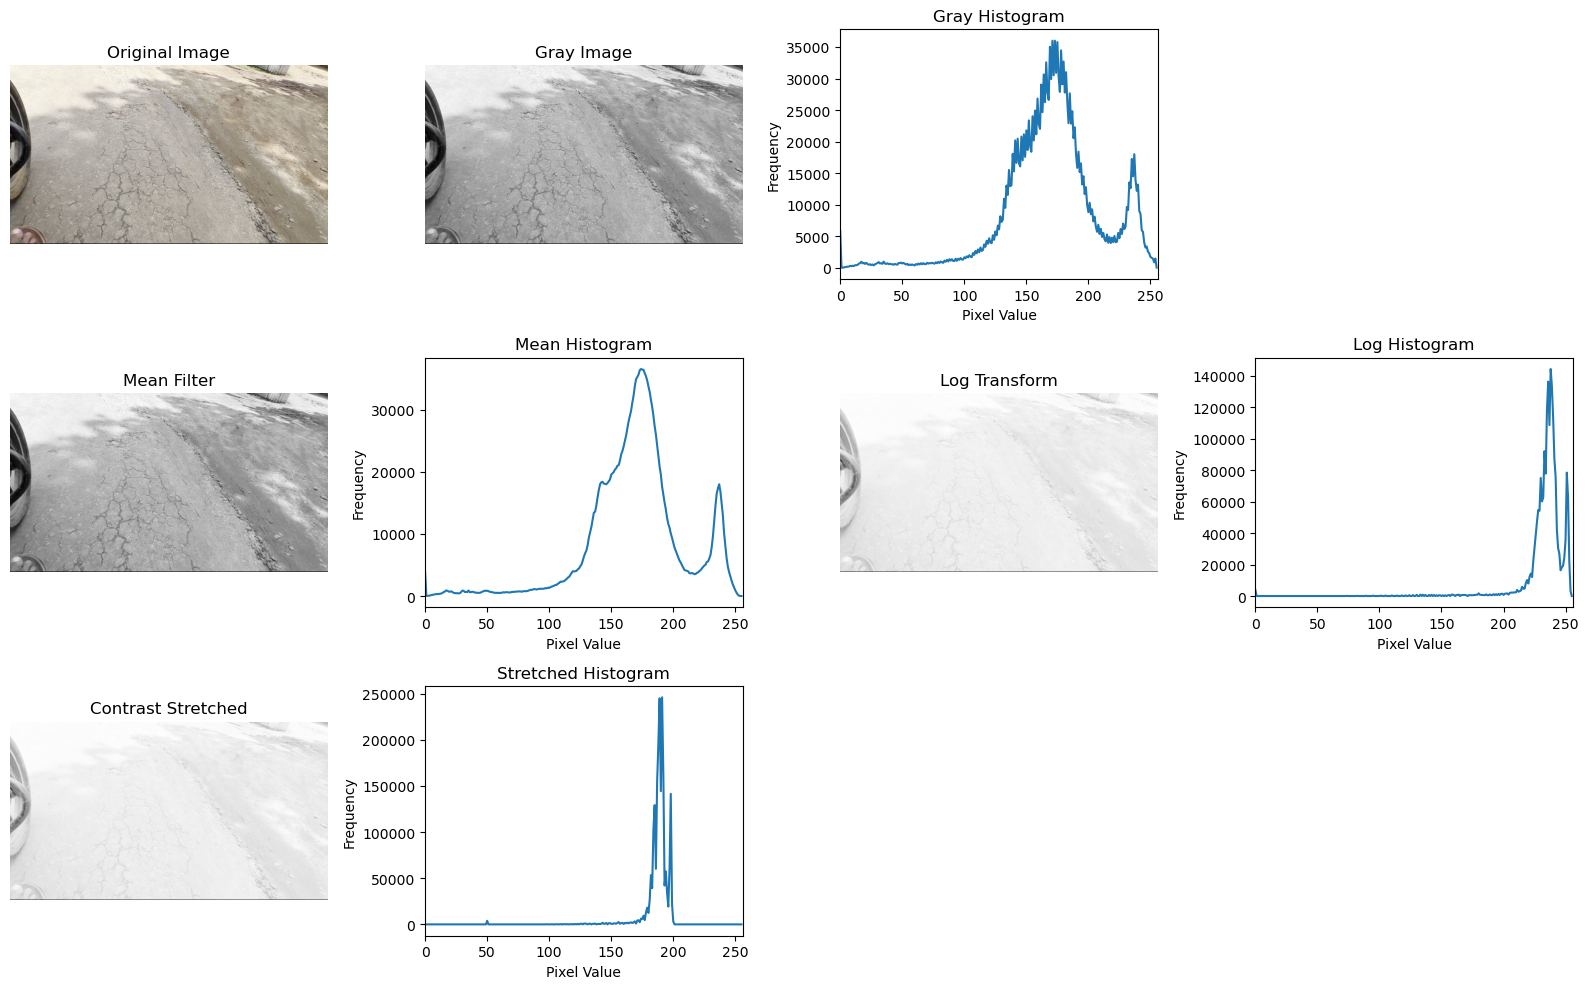

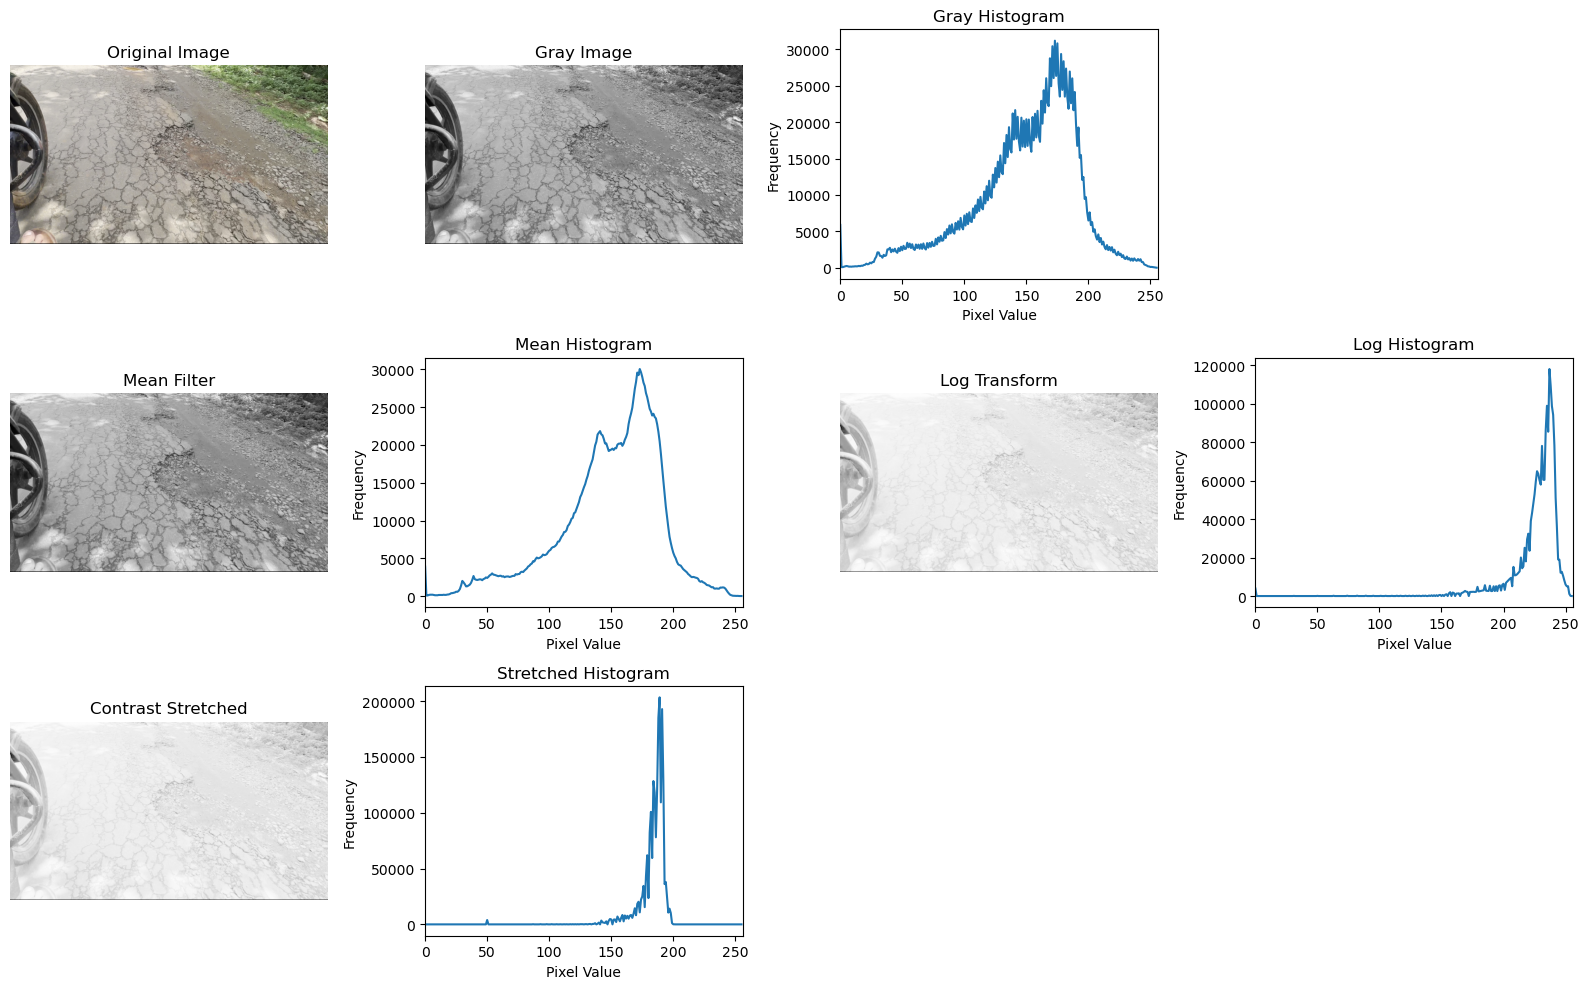

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

def plot_histogram(image, title):
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256])
    plt.plot(histogram)
    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])

def apply_mean_filter(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size ** 2)
    return cv2.filter2D(image, -1, kernel)

def apply_log_transformed(image):
    image2 = image.astype(np.float32)
    r_max = np.max(image)

    if r_max > 0:
        c = 255 / np.log(1 + r_max)
        log_transformed = c * np.log(1 + image2)
        return np.array(log_transformed, dtype=np.uint8)
    else:
        return image

def contrast_stretching(image):
    minval = np.min(image)
    maxval = np.max(image)

    if maxval == minval:
        return image

    dmin = 50
    dmax = 200
    stretched = dmin + (image - minval) * ((dmax - dmin) / (maxval - minval))
    return stretched.astype(np.uint8)


video_file_path = 'IMG_5985.mov'
cap = cv2.VideoCapture(video_file_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
random_frames = random.sample(range(total_frames), 30)

# 👉 Show first 3 frames (change to 30 if needed)
for frame_no in random_frames[:3]:

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
    ret, frame = cap.read()
    if not ret:
        continue

    # Convert BGR to RGB for correct display
    original = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    mean = apply_mean_filter(gray, 3)
    log_img = apply_log_transformed(mean)
    stretched = contrast_stretching(log_img)

    plt.figure(figsize=(16,10))

    # Row 1
    plt.subplot(3,4,1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(3,4,2)
    plt.imshow(gray, cmap='gray')
    plt.title("Gray Image")
    plt.axis('off')

    plt.subplot(3,4,3)
    plot_histogram(gray, "Gray Histogram")

    # Row 2
    plt.subplot(3,4,5)
    plt.imshow(mean, cmap='gray')
    plt.title("Mean Filter")
    plt.axis('off')

    plt.subplot(3,4,6)
    plot_histogram(mean, "Mean Histogram")

    plt.subplot(3,4,7)
    plt.imshow(log_img, cmap='gray')
    plt.title("Log Transform")
    plt.axis('off')

    plt.subplot(3,4,8)
    plot_histogram(log_img, "Log Histogram")

    # Row 3
    plt.subplot(3,4,9)
    plt.imshow(stretched, cmap='gray')
    plt.title("Contrast Stretched")
    plt.axis('off')

    plt.subplot(3,4,10)
    plot_histogram(stretched, "Stretched Histogram")

    plt.tight_layout()
    plt.show()

cap.release()